In [1]:
%config InlineBackend.figure_format = 'retina'

from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src import load_image, population, rendering
from src.ga import GeneticAlgorithm, fitness, mutate, cross_over


In [2]:
individual = population.create_random_individual()
individual[:5]

[Triangle(x1=248, y1=257, x2=143, y2=45, x3=114, y3=254, r=163, g=209, b=173, a=183),
 Triangle(x1=35, y1=265, x2=39, y2=203, x3=29, y3=96, r=27, g=2, b=45, a=157),
 Triangle(x1=157, y1=185, x2=142, y2=186, x3=140, y3=37, r=105, g=49, b=60, a=82),
 Triangle(x1=129, y1=199, x2=54, y2=197, x3=220, y3=250, r=110, g=141, b=112, a=173),
 Triangle(x1=17, y1=189, x2=7, y2=212, x3=297, y3=249, r=249, g=108, b=148, a=165)]

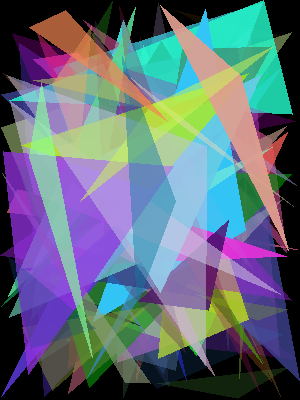

In [3]:
random_image = rendering.render_individual(individual=individual)
random_image

This random initialization confirms that the representation and rendering pipeline are functioning correctly.


In [4]:
# --- Import original paiting image --- #
image_path = os.path.join(project_root, "images/girl_pearl_earing.png")
target_array = load_image.load_target_image(image_path)
print(f"{target_array.shape} -> (H, W, 3) array with RGB values in [0, 255]")

(400, 300, 3) -> (H, W, 3) array with RGB values in [0, 255]


In [5]:
# --- Convert random first image to matrix and compute RMSE --- #
first_target_array = rendering.image_to_array(random_image)
fitness.compute_rmse(target=target_array, generated=first_target_array)

0.3470066785812378

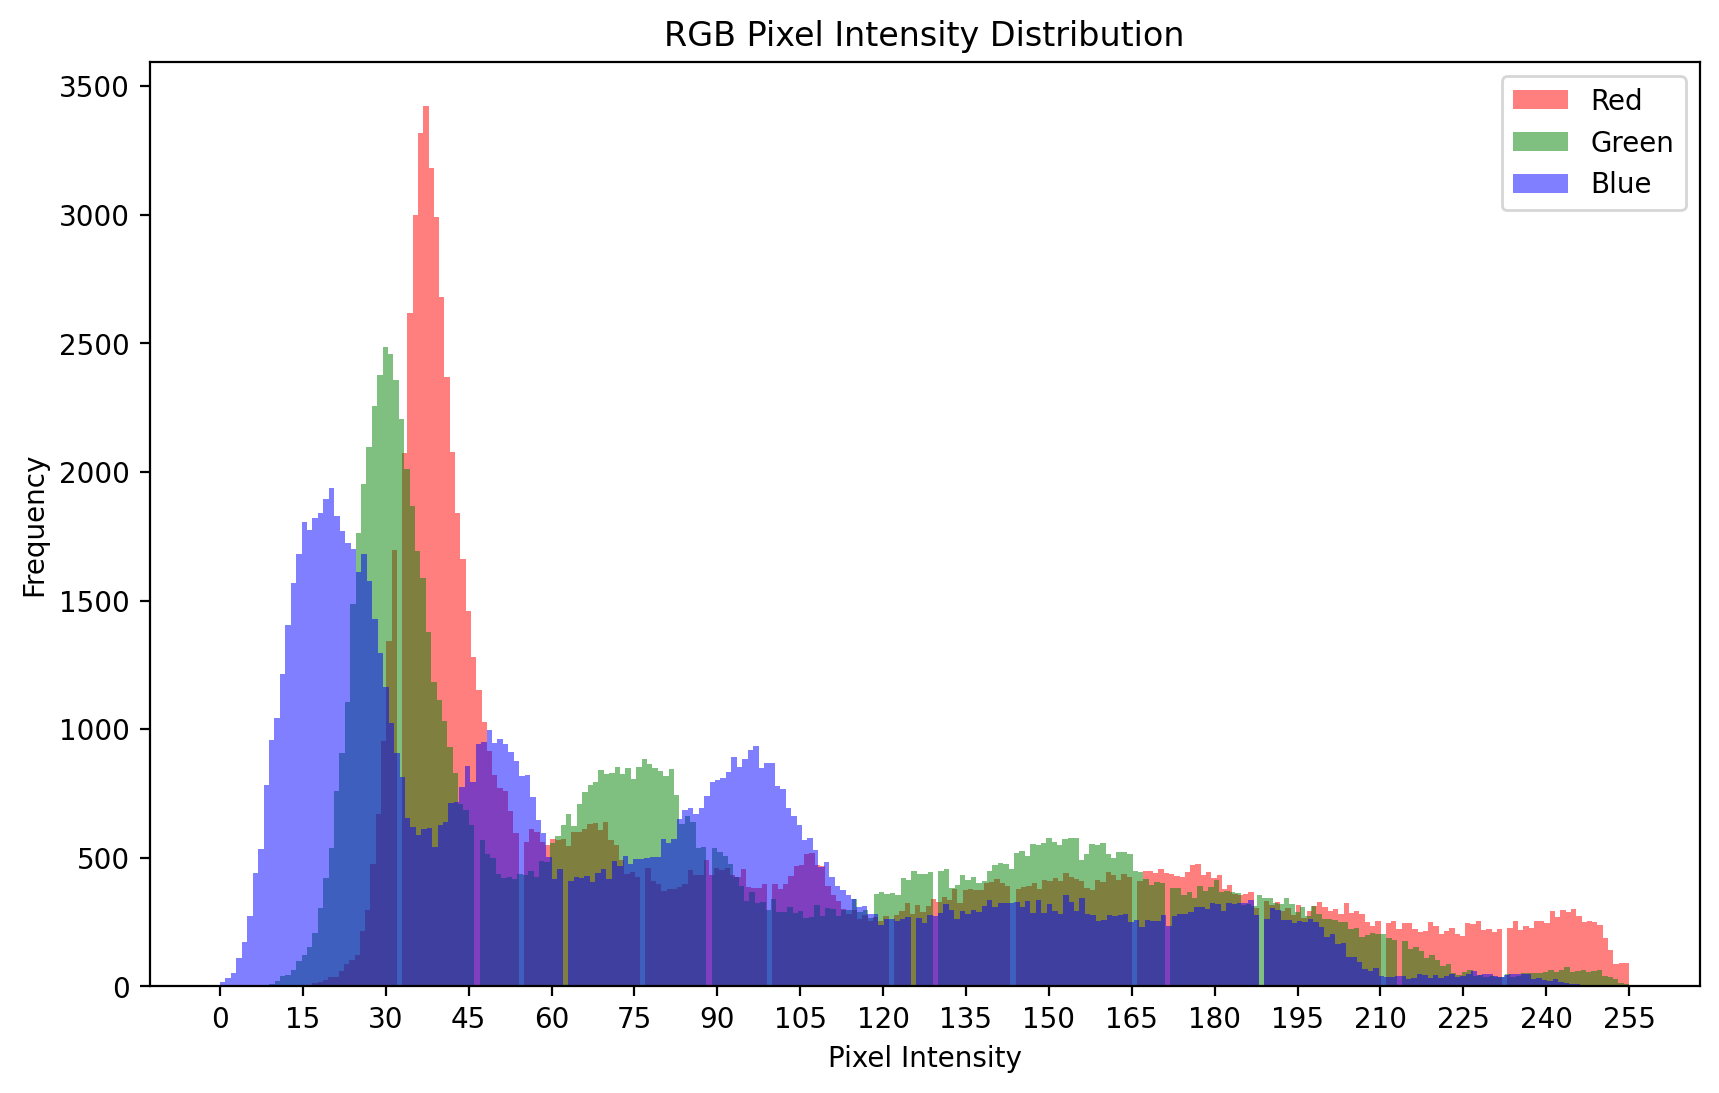

In [6]:
# Separate channels
r = target_array[:, :, 0].flatten()
g = target_array[:, :, 1].flatten()
b = target_array[:, :, 2].flatten()

# Plot histograms
plt.figure(figsize=(10, 6))
plt.hist(r, bins=256, color="red", alpha=0.5, label="Red")
plt.hist(g, bins=256, color="green", alpha=0.5, label="Green")
plt.hist(b, bins=256, color="blue", alpha=0.5, label="Blue")

plt.xticks(np.arange(0, 256, 15))  # ticks every 25
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("RGB Pixel Intensity Distribution")
plt.legend()
plt.show()

In [ ]:
ga = GeneticAlgorithm(
    target=target_array,
    triangle_alpha_range=(255, 255),
    fitness_function=fitness.compute_rmse,
    population_size=200,
    generations=800,
    crossover_function=cross_over.two_point_crossover,
    crossover_rate=0.9,
    mutation_function=mutate.volatile_triangle_mutation,
    mutation_rate=0.1,
    elitism=2,
    selection_type="tournament",
    logs=True,
    evaluation_backend="process",
    n_jobs=8,
    chunksize=5,
    progress=True,
    progress_interval=10
)

best_fitness, history = ga.run()
best_individual = ga.best_individual

In [8]:
from src.ga import LegacyPipelineConfig, run_legacy_pipeline, fitness

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
image_path = project_root / "images/girl_pearl_earing.png"  # change if needed
target_image = load_image.load_target_image(image_path)

legacy_config = LegacyPipelineConfig(
    population_size=200,
    generations=400,
    n_triangles=100,
    elitism_fraction=0.2,
    tournament_size=3,
    mutation_rate=0.15,
    position_sigma=0.05,
    color_sigma=0.08,
    stagnation_boost_window=15,
    diversity_window=30,
    local_search_steps=50,
    evaluation_backend="process",  # or "sequential" / "thread"
    n_jobs=8,
    chunksize=8,
    seed=42,
    progress=True,
    progress_interval=10,
)

legacy_result = run_legacy_pipeline(
    target=target_image,
    config=legacy_config,
    fitness_function=fitness.compute_rmse,
)

best_fitness = legacy_result.best_fitness
history = legacy_result.history
best_individual = legacy_result.best_individual
generation_logs = legacy_result.generation_logs

[LEGACY] gen 1/400 | best=0.277248 | gen_best=0.277248 | sigmas=(0.0500, 0.0800) | stagnation=0
[LEGACY] gen 11/400 | best=0.223201 | gen_best=0.224866 | sigmas=(0.0500, 0.0800) | stagnation=2
[LEGACY] gen 21/400 | best=0.201978 | gen_best=0.201978 | sigmas=(0.0500, 0.0800) | stagnation=0
[LEGACY] gen 31/400 | best=0.193079 | gen_best=0.193079 | sigmas=(0.0500, 0.0800) | stagnation=0
[LEGACY] gen 41/400 | best=0.182047 | gen_best=0.182047 | sigmas=(0.0500, 0.0800) | stagnation=0
[LEGACY] gen 51/400 | best=0.180556 | gen_best=0.180556 | sigmas=(0.0500, 0.0800) | stagnation=0
[LEGACY] gen 61/400 | best=0.176005 | gen_best=0.177420 | sigmas=(0.0500, 0.0800) | stagnation=2
[LEGACY] gen 71/400 | best=0.174948 | gen_best=0.175157 | sigmas=(0.0500, 0.0800) | stagnation=2
[LEGACY] gen 81/400 | best=0.170528 | gen_best=0.170827 | sigmas=(0.0500, 0.0800) | stagnation=1
[LEGACY] gen 91/400 | best=0.167701 | gen_best=0.168782 | sigmas=(0.0500, 0.0800) | stagnation=1
[LEGACY] gen 101/400 | best=0.1

In [9]:
rendering.render_individual(individual=ga.best_individual)

NameError: name 'ga' is not defined